# 실전 14-1: 멀티모달 기초 (Vision API)

## 1. LLM에게 시각(Vision) 능력 달아주기
- 텍스트로만 소통하던 LLM(Large Language Model)이 이제 LMM(Large Multimodal Model)으로 진화했습니다.
- OpenAI의 `gpt-4o`나 `gpt-4o-mini` 모델은 기본적으로 Vision 능력을 탑재하고 있습니다.
- 로컬에 있는 이미지 파일을 **Base64** 형태로 인코딩해서 프롬프트에 실어 보내면, AI가 이미지를 텍스트처럼 읽어냅니다.

In [1]:
import os
import base64
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 2. 이미지 불러오기 및 렌더링
실습을 위해 준비된 영수증(Receipt) 샘플 이미지를 화면에 띄워봅니다.

=== [원본 이미지 확인] ===


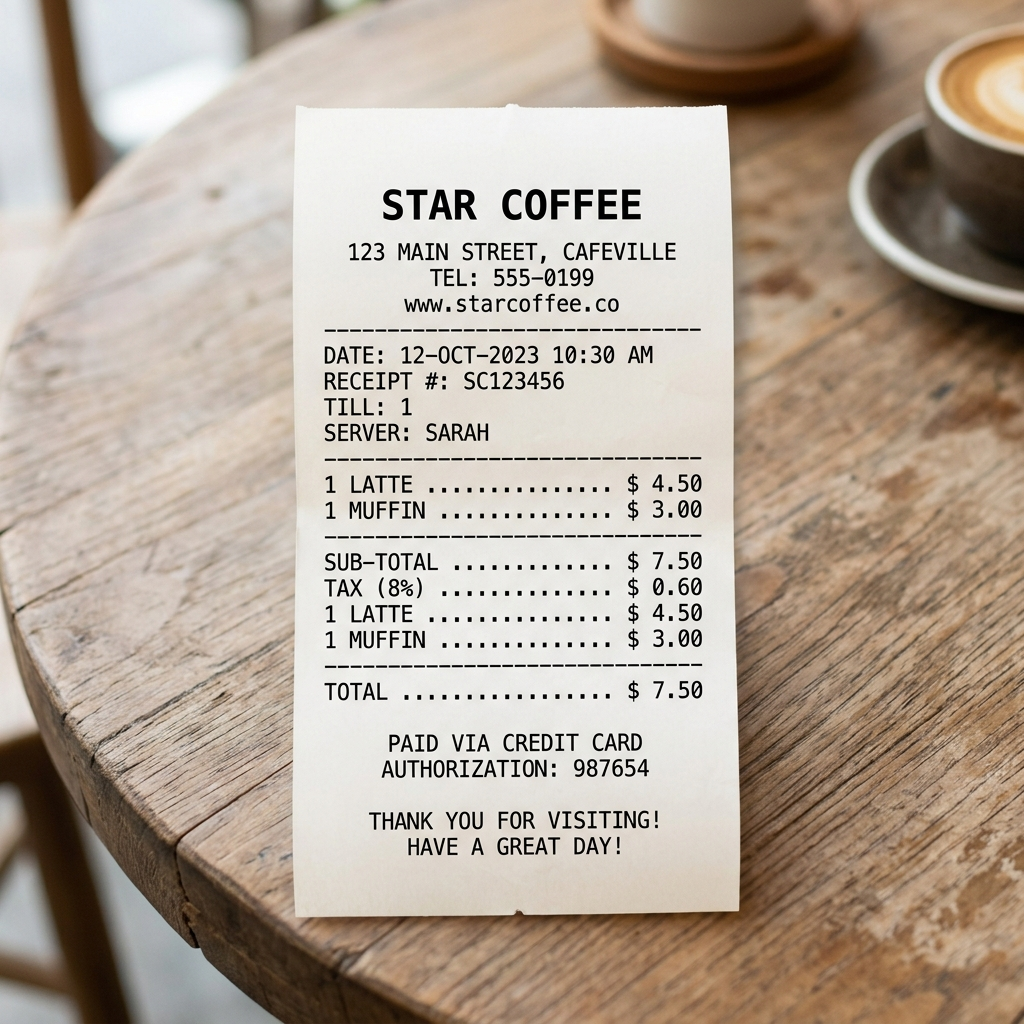

In [2]:
from IPython.display import Image, display

image_path = "images/receipt.png"

print("=== [원본 이미지 확인] ===")
display(Image(filename=image_path, width=300))

## 3. Base64 인코딩 및 LLM에 전송
컴퓨터에 있는 이미지 파일을 LLM API로 쏘기 위해서는, 사진 데이터를 거대한 텍스트 덩어리(Base64)로 변환해야 합니다.

In [3]:
# 1. 이미지를 Base64 텍스트로 변환하는 헬퍼 함수
def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

base64_image = encode_image_to_base64(image_path)

# 2. LangChain의 HumanMessage 규격에 맞게 텍스트와 이미지를 리스트 형태로 묶어서 전달합니다.
message = HumanMessage(
    content=[
        {"type": "text", "text": "이 영수증에 적힌 내용을 바탕으로 결제한 가게 이름과, 구입한 품목들, 그리고 총 결제 금액을 알려줘."},
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/png;base64,{base64_image}"}
        }
    ]
)

print("=== [LLM의 시각 분석 결과] ===")
response = llm.invoke([message])
print(response.content)

=== [LLM의 시각 분석 결과] ===
결제한 가게 이름: **STAR COFFEE**

구입한 품목들:
- 1 LATTE
- 1 MUFFIN

총 결제 금액: **$7.50**


## 4. 결론
- 기존에는 이미지의 글자를 읽기 위해 무거운 OCR 라이브러리(Tesseract, Google Vision API 등)를 따로 붙여야 했습니다.
- 이제는 GPT-4o 하나로 텍스트 이해와 이미지 분석(OCR 포함)이 동시에, 그것도 문맥(Context)에 맞게 완벽하게 이루어집니다.